# 06 — Real-data setup and audit

This notebook inspects a dataset produced by `scripts/prepare_btc_lob.py`. Training remains in scripts.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path('../data/processed/btc_h40_cost')
PROCESSED_DIR

PosixPath('../data/processed/btc_h40_cost')

In [2]:
metadata_path = PROCESSED_DIR / 'metadata.json'
if not metadata_path.exists():
    print('Prepare the raw BTC dataset first. See docs/REAL_DATA_PIPELINE.md')
    metadata = None
else:
    metadata = json.loads(metadata_path.read_text())
    display(pd.Series(metadata, dtype='object'))

source                       /home/shuaigou2025/projects/cost-aware-limit-o...
dataset_type                                                 raw_lob_snapshots
preparation_mode                                         chunked_memory_mapped
n_observations                                                         3730870
n_features                                                                  40
n_days                                                                      12
day_labels                   [2023-01-09, 2023-01-10, 2023-01-11, 2023-01-1...
horizon                                                                     40
sequence_length                                                            100
label_type                                                          cost-aware
threshold_bps                                                              1.0
fee_bps_per_side                                                           1.0
slippage_bps_per_side                               

In [3]:
if metadata is not None:
    labels = np.load(PROCESSED_DIR / 'labels.npy', mmap_mode='r')
    splits = np.load(PROCESSED_DIR / 'splits.npz')
    rows = []
    for split_name in ('train', 'validation', 'test'):
        values = labels[splits[split_name]]
        counts = np.bincount(values, minlength=3)
        rows.append({'split': split_name, 'down/short': counts[0], 'flat': counts[1], 'up/long': counts[2]})
    display(pd.DataFrame(rows).set_index('split'))

,down/short,flat,up/long
split,,,
train,200660,2025675,209037
validation,66764,555865,66026
test,26757,548099,30319


In [4]:
if metadata is not None:
    source = np.load(PROCESSED_DIR / 'source_features.npy', mmap_mode='r')
    timestamps = np.load(PROCESSED_DIR / 'timestamps.npy')
    ask = source[:, 0]
    bid = source[:, 2]
    mid = (ask + bid) / 2
    spread_bps = (ask - bid) / mid * 10_000
    audit = pd.DataFrame({
        'timestamp': pd.to_datetime(timestamps),
        'midprice': mid,
        'spread_bps': spread_bps,
    })
    display(audit.describe(include='all'))

,timestamp,midprice,spread_bps
count,3730870,3.730870e+06,3.730870e+06
mean,2023-01-15 08:13:33.620902400,1.986779e+04,5.440792e-02
min,2023-01-09 22:17:40.926000,1.711835e+04,4.598802e-02
25%,2023-01-12 15:15:35.967000064,1.822435e+04,4.751574e-02
50%,2023-01-15 08:13:07.073500160,2.078375e+04,4.806231e-02
75%,2023-01-18 01:11:56.072499968,2.104865e+04,5.472185e-02
max,2023-01-20 18:10:48.672000,2.165985e+04,7.610314e+01
std,NaN,1.518495e+03,1.353823e-01


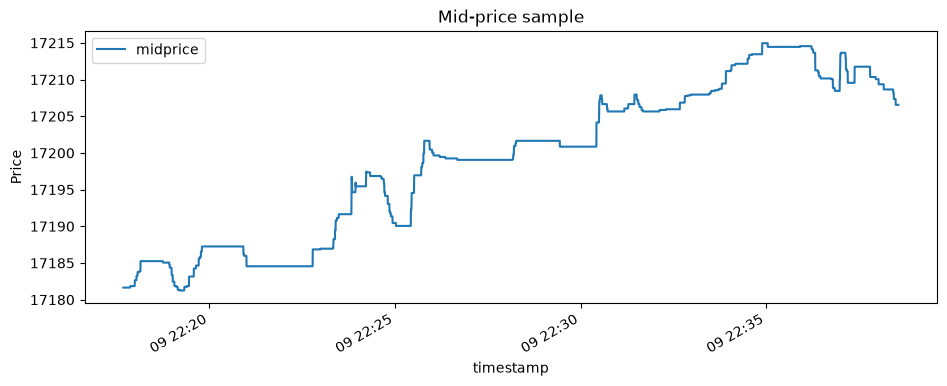

In [5]:
if metadata is not None:
    sample = audit.iloc[: min(5000, len(audit))]
    ax = sample.plot(x='timestamp', y='midprice', title='Mid-price sample', figsize=(11, 4))
    ax.set_ylabel('Price')
    plt.show()

In [6]:
if metadata is not None:
    names = json.loads((PROCESSED_DIR / 'tabular_feature_names.json').read_text())
    tabular = np.load(PROCESSED_DIR / 'tabular_features.npy', mmap_mode='r')
    display(pd.DataFrame(tabular[:5], columns=names))

,spread,relative_spread,midprice,microprice,microprice_deviation,ask_depth_1,bid_depth_1,imbalance_1,ask_depth_5,bid_depth_5,imbalance_5,ask_depth_10,bid_depth_10,imbalance_10,log_mid_return_1,relative_spread_change_1,imbalance_1_change_1,realized_volatility_4,realized_volatility_20
0,-0.027749,0.011858,-1.33744,-1.337425,0.234044,-0.517029,0.175064,0.706597,-0.347961,0.277904,0.562865,-0.011823,0.226263,0.196516,-0.001785,7.945155e-07,0.000004,-0.380231,-0.571163
1,-0.027749,0.011858,-1.33744,-1.337422,0.270524,-0.534642,0.212441,0.751146,-0.426637,0.305138,0.675544,-0.088094,0.249964,0.282731,-0.001785,7.945155e-07,0.089506,-0.380231,-0.571163
2,-0.027749,0.011858,-1.33744,-1.337422,0.270524,-0.534597,0.219865,0.754499,-0.423792,0.310895,0.674770,-0.067008,0.254974,0.266440,-0.001785,7.945155e-07,0.006741,-0.380231,-0.571163
3,-0.027749,0.011858,-1.33744,-1.337422,0.270524,-0.559649,0.240312,0.801605,-0.407846,0.326381,0.662220,-0.035560,0.268450,0.246963,-0.001785,7.945155e-07,0.094642,-0.380231,-0.571163
4,-0.027749,0.011858,-1.33744,-1.337421,0.288764,-0.581141,0.219865,0.826723,-0.428955,0.310525,0.681275,-0.053754,0.255647,0.254706,-0.001785,7.945155e-07,0.050469,-0.380231,-0.571163


## Audit checklist

- Confirm snapshot frequency and gaps.
- Confirm no crossed books.
- Inspect duplicate-timestamp policy.
- Check class balance by day.
- Check spread and volatility regimes.
- Confirm costs and label horizon match the planned backtest.